**Import Libraries**

In [1]:
import os
import dotenv 
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
import numpy as np
from src.dataset import MRIDataset
from src.unet3d_dae import UNet3D
import torch
from torch.utils.data import DataLoader
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

torch.manual_seed(32)

##### 1. MSLUB

In [2]:
# Define data path
mslub_t1_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\MSLUB-T1')
mslub_t2_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\MSLUB-T2')
mslub_gt_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\MSLUB-GT')

# Define dataset 
mslub_t1_dataset = MRIDataset(npz_dir=mslub_t1_dir, is_training=False, mol=1)
mslub_t2_dataset = MRIDataset(npz_dir=mslub_t2_dir, is_training=False, mol=2)

# mslub_t1_dataset.files = mslub_t1_dataset.files[:1]
# mslub_t2_dataset.files = mslub_t2_dataset.files[:1]

# Create DataLoaders
mslub_t1_test_loader = DataLoader(mslub_t1_dataset, batch_size=1)
mslub_t2_test_loader = DataLoader(mslub_t2_dataset, batch_size=1)

##### 1.2 Inference

In [3]:
def dice_score(pred, gt):
    smooth = 1e-8
    intersection = torch.sum(pred * gt)
    union = torch.sum(pred) + torch.sum(gt)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.item()

def best_dice_score(residual_map, ground_truth, steps=1000):
    best_dice = 0.0
    best_thresh = 0.0

    for t in torch.linspace(0, 1, steps):
        pred_binary = (residual_map > t).int()
        dice = dice_score(pred_binary, ground_truth.int())

        if dice > best_dice:
            best_dice = dice
            best_thresh = t.item()

    return best_dice, best_thresh

def compute_aurpc(residual, ground_truth):
    y_true = ground_truth.cpu().numpy().flatten()
    y_scores = residual.cpu().numpy().flatten()
    
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    aurpc = auc(recall, precision)
    
    return aurpc

In [4]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the selected device
model = UNet3D().to(device)
model.load_state_dict(torch.load(os.path.join(os.getenv('PROJECT_ROOT'), r'model\full_model_weights.pth'), map_location=torch.device('cpu')))
model.eval()

UNet3D(
  (down1): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film1): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish1): Swish()
      (conv2): WSConv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film2): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish2): Swish()
    )
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 64, eps=1e-05, aff

In [5]:
# Initialize loss tracking
mslub_t1_total_dice = 0.0
mslub_t1_total_aurpc = 0.0

# Loop through testing dataset
for mslub_t1_image, _, mslub_t1_modality, mslub_t1_file_name in mslub_t1_test_loader:
    mslub_t1_image, mslub_t1_modality= mslub_t1_image.to(device), mslub_t1_modality.to(device)
    mslub_t1_file_name = mslub_t1_file_name[0]
    mslub_t1_base_name = os.path.basename(mslub_t1_file_name)[:10] 
    mslub_t1_ground_truth_file = os.path.join(mslub_gt_dir, f'{mslub_t1_base_name}consensus_gt.npz')
    mslub_t1_ground_truth_np = np.load(mslub_t1_ground_truth_file)['ground_truth']
    mslub_t1_ground_truth = torch.tensor(mslub_t1_ground_truth_np, dtype=torch.uint8)
    mslub_t1_ground_truth = mslub_t1_ground_truth.squeeze()
    
    with torch.no_grad():
        mslub_t1_reconstruction = model(mslub_t1_image, mslub_t1_modality)
        mslub_t1_residual = torch.abs(mslub_t1_image - mslub_t1_reconstruction)

        # Apply 3D median filtering
        mslub_t1_residual_np = mslub_t1_residual.squeeze().cpu().numpy()
        mslub_t1_filtered_residual = median_filter(mslub_t1_residual_np, size=5)
        # mslub_t1_filtered_residual = mslub_t1_residual_np.copy()
        mslub_t1_filtered_residual = torch.tensor(mslub_t1_filtered_residual, dtype=mslub_t1_residual.dtype)

        # Compute dice score and AURPC
        mslub_t1_dice, mslub_t1_optimal_thresh = best_dice_score(mslub_t1_filtered_residual, mslub_t1_ground_truth)
        print(mslub_t1_dice)
        mslub_t1_aurpc = compute_aurpc(mslub_t1_filtered_residual, mslub_t1_ground_truth)
        mslub_t1_total_dice += mslub_t1_dice
        mslub_t1_total_aurpc += mslub_t1_aurpc

mslub_t1_num_samples = len(mslub_t1_test_loader.dataset)

mslub_t1_avg_dice = mslub_t1_total_dice / mslub_t1_num_samples
mslub_t1_avg_aurpc = mslub_t1_total_aurpc / mslub_t1_num_samples

print(f"MSLUB Average T1 Dice Score: {mslub_t1_avg_dice:.4f}")
print(f"MSLUB Average T1 AURPC: {mslub_t1_avg_aurpc:.4f}")

0.020443210378289223
0.0004475479945540428
0.00038364750798791647
0.05516819655895233
0.02322317846119404
0.034977126866579056
0.0007738632848486304
0.005909983068704605
0.014775030314922333
0.03537920117378235
0.010171393863856792
0.022209100425243378
0.06884628534317017
0.007710635662078857
0.017548013478517532
0.009897444397211075
0.0008654440753161907
0.00026978523237630725
0.10509929805994034
0.0030062294099479914
0.021250354126095772
0.013203087262809277
0.008547751232981682
0.0011599245481193066
0.012226195074617863
0.0048227510415017605
0.0006649438291788101
0.0038612924981862307
5.867757499800064e-05
0.00019236317893955857
MSLUB Average T1 Dice Score: 0.0168
MSLUB Average T1 AURPC: 0.0072


In [6]:
# Initialize loss tracking
mslub_t2_total_dice = 0.0
mslub_t2_total_aurpc = 0.0

# Loop through testing dataset
for mslub_t2_image, _, mslub_t2_modality, mslub_t2_file_name in mslub_t2_test_loader:
    mslub_t2_image, mslub_t2_modality = mslub_t2_image.to(device), mslub_t2_modality.to(device)
    mslub_t2_file_name = mslub_t2_file_name[0]
    mslub_t2_base_name = os.path.basename(mslub_t2_file_name)[:10]
    mslub_t2_ground_truth_file = os.path.join(mslub_gt_dir, f'{mslub_t2_base_name}consensus_gt.npz')
    mslub_t2_ground_truth_np = np.load(mslub_t2_ground_truth_file)['ground_truth']
    mslub_t2_ground_truth = torch.tensor(mslub_t2_ground_truth_np, dtype=torch.uint8)
    mslub_t2_ground_truth = mslub_t2_ground_truth.squeeze()
    
    with torch.no_grad():
        mslub_t2_reconstruction = model(mslub_t2_image, mslub_t2_modality)
        mslub_t2_residual = torch.abs(mslub_t2_image - mslub_t2_reconstruction)

        # Apply 3D median filtering
        mslub_t2_residual_np = mslub_t2_residual.squeeze().cpu().numpy()
        mslub_t2_filtered_residual = median_filter(mslub_t2_residual_np, size=5)
        mslub_t2_filtered_residual = torch.tensor(mslub_t2_filtered_residual, dtype=mslub_t2_residual.dtype)

        # Compute dice score and AURPC
        mslub_t2_dice, mslub_t2_optimal_thresh = best_dice_score(mslub_t2_filtered_residual, mslub_t2_ground_truth)
        mslub_t2_aurpc = compute_aurpc(mslub_t2_filtered_residual, mslub_t2_ground_truth)
        mslub_t2_total_dice += mslub_t2_dice
        mslub_t2_total_aurpc += mslub_t2_aurpc

mslub_t2_num_samples = len(mslub_t2_test_loader.dataset)

mslub_t2_avg_dice = mslub_t2_total_dice / mslub_t2_num_samples
mslub_t2_avg_aurpc = mslub_t2_total_aurpc / mslub_t2_num_samples

print(f"MSLUB Average T2 Dice Score: {mslub_t2_avg_dice:.4f}")
print(f"MSLUB Average T2 AURPC: {mslub_t2_avg_aurpc:.4f}")

MSLUB Average T2 Dice Score: 0.0077
MSLUB Average T2 AURPC: 0.0021


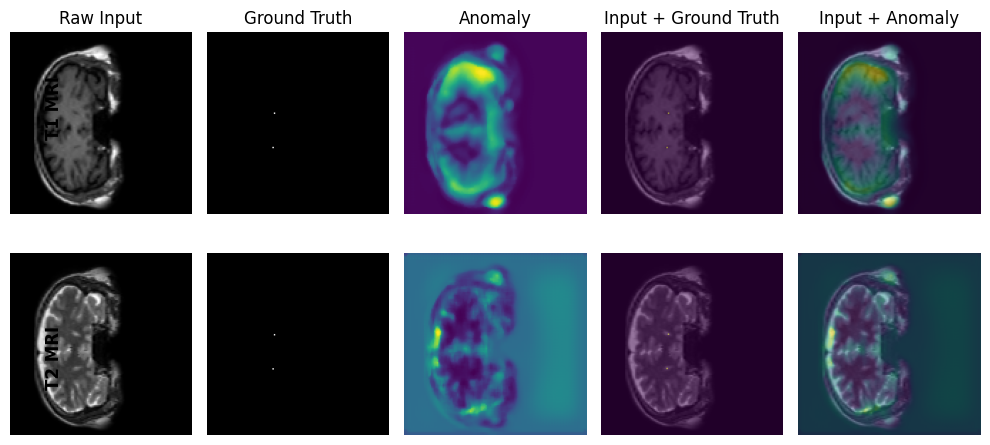

In [8]:
# Visualization of reconstructions 
mslub_t1_raw = mslub_t1_image.cpu().numpy()
mslub_t1_anomaly = mslub_t1_filtered_residual.numpy()
mslub_t1_gt = mslub_t1_ground_truth.numpy()

mslub_t2_raw = mslub_t2_image.cpu().numpy()
mslub_t2_anomaly = mslub_t2_filtered_residual.numpy()
mslub_t2_gt = mslub_t2_ground_truth.numpy()

# Create subplots 
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Extract middle slices along depth
mslub_t1_raw_slice = mslub_t1_raw[0, 0, :, 50, :]
mslub_t1_anomaly_slice = mslub_t1_anomaly[:, 50, :]  
mslub_t1_gt_slice = mslub_t1_gt[:, 50, :]

mslub_t2_raw_slice = mslub_t2_raw[0, 0, :, 50, :]
mslub_t2_anomaly_slice = mslub_t2_anomaly[:, 50, :]
mslub_t2_gt_slice = mslub_t2_gt[:, 50, :]

# Plot T1 slices (row 0)
axes[0,0].imshow(mslub_t1_raw_slice, cmap="gray") 
axes[0,1].imshow(mslub_t1_gt_slice, cmap="gray")
axes[0,2].imshow(mslub_t1_anomaly_slice, cmap="viridis") 
axes[0,3].imshow(mslub_t1_raw_slice, cmap="gray") 
axes[0,3].imshow(mslub_t1_gt_slice, cmap="viridis", alpha=0.5) 
axes[0,4].imshow(mslub_t1_raw_slice, cmap="gray") 
axes[0,4].imshow(mslub_t1_anomaly_slice, cmap="viridis", alpha=0.5) 

# Plot T2 slices (row 1)
axes[1,0].imshow(mslub_t2_raw_slice, cmap="gray") 
axes[1,1].imshow(mslub_t2_gt_slice, cmap="gray")
axes[1,2].imshow(mslub_t2_anomaly_slice, cmap="viridis") 
axes[1,3].imshow(mslub_t2_raw_slice, cmap="gray") 
axes[1,3].imshow(mslub_t2_gt_slice, cmap="viridis", alpha=0.5) 
axes[1,4].imshow(mslub_t2_raw_slice, cmap="gray") 
axes[1,4].imshow(mslub_t2_anomaly_slice, cmap="viridis", alpha=0.5)

# Remove axis labels
for row in range(2):
    for col in range(5):
        axes[row, col].axis("off")

# Set column titles
axes[0,0].set_title("Raw Input")
axes[0,1].set_title("Ground Truth")
axes[0,2].set_title("Anomaly")
axes[0,3].set_title("Input + Ground Truth")
axes[0,4].set_title("Input + Anomaly")

# Add row labels (T1 and T2) using fig.text()
fig.text(0.05, 0.75, "T1 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)
fig.text(0.05, 0.25, "T2 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)

plt.tight_layout()
plt.show()

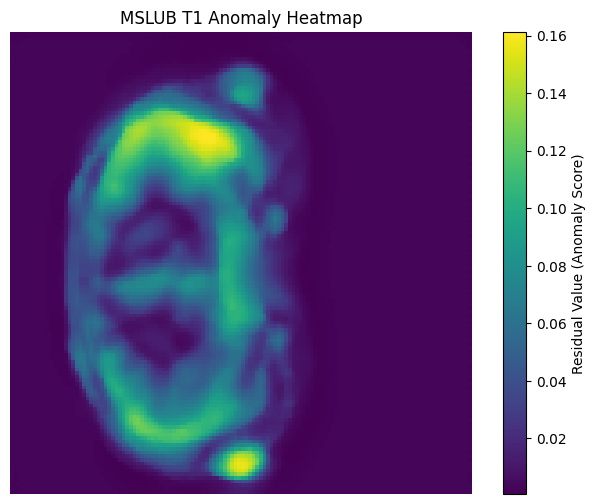

In [9]:
# Plot heatmap with colorbar
plt.figure(figsize=(8, 6))
mslub_t1_heatmap = plt.imshow(mslub_t1_anomaly_slice, cmap="viridis")   
plt.colorbar(mslub_t1_heatmap, label="Residual Value (Anomaly Score)")  
plt.title("MSLUB T1 Anomaly Heatmap")
plt.axis("off")
plt.show()

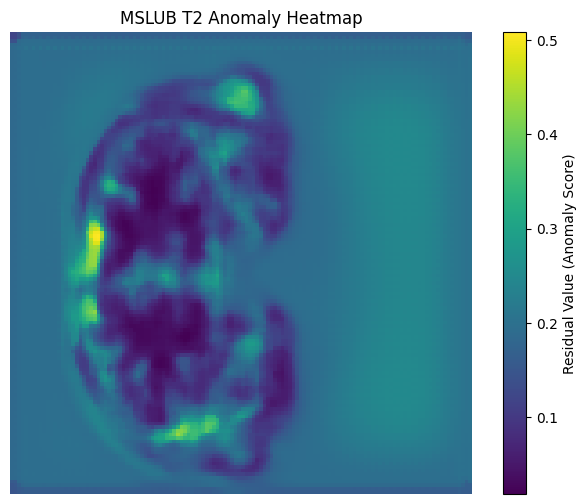

In [10]:
# Plot heatmap with colorbar
plt.figure(figsize=(8, 6))
mslub_t2_heatmap = plt.imshow(mslub_t2_anomaly_slice, cmap="viridis")   
plt.colorbar(mslub_t2_heatmap, label="Residual Value (Anomaly Score)")  
plt.title("MSLUB T2 Anomaly Heatmap")
plt.axis("off")
plt.show()

##### 2. BraTs

In [11]:
# Define data path
brats_t1_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data/BraTS-T1')
brats_t2_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data/BraTS-T2')
brats_gt_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data/BraTS-GT')

# Define dataset
brats_t1_dataset = MRIDataset(npz_dir=brats_t1_dir, is_training=False, mol=1)
brats_t2_dataset = MRIDataset(npz_dir=brats_t2_dir, is_training=False, mol=2)

# Create DataLoaders
brats_t1_test_loader = DataLoader(brats_t1_dataset, batch_size=1)
brats_t2_test_loader = DataLoader(brats_t2_dataset, batch_size=1)

In [16]:
# Initialize loss tracking
brats_t1_total_dice = 0.0
brats_t1_total_aurpc = 0.0

# Loop through testing dataset
for brats_t1_image, _, brats_t1_modality, brats_t1_file_name in brats_t1_test_loader:
    brats_t1_image, brats_t1_modality = brats_t1_image.to(device), brats_t1_modality.to(device)
    brats_t1_file_name = brats_t1_file_name[0]
    brats_t1_base_name = os.path.basename(brats_t1_file_name)[:21] 
    brats_t1_ground_truth_file = os.path.join(brats_gt_dir, f'{brats_t1_base_name}seg.npz')
    brats_t1_ground_truth_np = np.load(brats_t1_ground_truth_file)['ground_truth']
    brats_t1_ground_truth = torch.tensor(brats_t1_ground_truth_np, dtype=torch.uint8)
    brats_t1_ground_truth = brats_t1_ground_truth.squeeze()
    brats_t1_ground_truth = (brats_t1_ground_truth != 0).to(torch.uint8)
    
    with torch.no_grad():
        brats_t1_reconstruction = model(brats_t1_image, brats_t1_modality)
        brats_t1_residual = torch.abs(brats_t1_image - brats_t1_reconstruction)

        # Apply 3D median filtering
        brats_t1_residual_np = brats_t1_residual.squeeze().cpu().numpy()
        brats_t1_filtered_residual = median_filter(brats_t1_residual_np, size=5)
        brats_t1_filtered_residual = torch.tensor(brats_t1_filtered_residual, dtype=brats_t1_residual.dtype)

        # Compute dice score and AURPC
        brats_t1_dice, brats_t1_optimal_thresh = best_dice_score(brats_t1_filtered_residual, brats_t1_ground_truth)
        brats_t1_aurpc = compute_aurpc(brats_t1_filtered_residual, brats_t1_ground_truth)
        brats_t1_total_dice += brats_t1_dice
        brats_t1_total_aurpc += brats_t1_aurpc

brats_t1_num_samples = len(brats_t1_test_loader.dataset)

brats_t1_avg_dice = brats_t1_total_dice / brats_t1_num_samples
brats_t1_avg_aurpc = brats_t1_total_aurpc / brats_t1_num_samples

print(f"BRATS Average T1 Dice Score: {brats_t1_avg_dice:.4f}")
print(f"BRATS Average T1 AURPC: {brats_t1_avg_aurpc:.4f}")


BRATS Average T1 Dice Score: 0.1593
BRATS Average T1 AURPC: 0.0950


In [17]:
# Initialize loss tracking
brats_t2_total_dice = 0.0
brats_t2_total_aurpc = 0.0

# Loop through testing dataset
for brats_t2_image, _, brats_t2_modality, brats_t2_file_name in brats_t2_test_loader:
    brats_t2_image, brats_t2_modality = brats_t2_image.to(device), brats_t2_modality.to(device)
    brats_t2_file_name = brats_t2_file_name[0]
    brats_t2_base_name = os.path.basename(brats_t2_file_name)[:21] 
    brats_t2_ground_truth_file = os.path.join(brats_gt_dir, f'{brats_t2_base_name}seg.npz')
    brats_t2_ground_truth_np = np.load(brats_t2_ground_truth_file)['ground_truth']
    brats_t2_ground_truth = torch.tensor(brats_t2_ground_truth_np, dtype=torch.uint8)
    brats_t2_ground_truth = brats_t2_ground_truth.squeeze()
    brats_t2_ground_truth = (brats_t2_ground_truth != 0).to(torch.uint8)
    
    with torch.no_grad():
        brats_t2_reconstruction = model(brats_t2_image, brats_t2_modality)
        brats_t2_residual = torch.abs(brats_t2_image - brats_t2_reconstruction)

        # Apply 3D median filtering
        brats_t2_residual_np = brats_t2_residual.squeeze().cpu().numpy()
        brats_t2_filtered_residual = median_filter(brats_t2_residual_np, size=5)
        brats_t2_filtered_residual = torch.tensor(brats_t2_filtered_residual, dtype=brats_t2_residual.dtype)

        # Compute dice score and AURPC
        brats_t2_dice, brats_t2_optimal_thresh = best_dice_score(brats_t2_filtered_residual, brats_t2_ground_truth)
        brats_t2_aurpc = compute_aurpc(brats_t2_filtered_residual, brats_t2_ground_truth)
        brats_t2_total_dice += brats_t2_dice
        brats_t2_total_aurpc += brats_t2_aurpc

brats_t2_num_samples = len(brats_t2_test_loader.dataset)

brats_t2_avg_dice = brats_t2_total_dice / brats_t2_num_samples
brats_t2_avg_aurpc = brats_t2_total_aurpc / brats_t2_num_samples

print(f"BRATS Average T2 Dice Score: {brats_t2_avg_dice:.4f}")
print(f"BRATS Average T2 AURPC: {brats_t2_avg_aurpc:.4f}")


BRATS Average T2 Dice Score: 0.2223
BRATS Average T2 AURPC: 0.1087


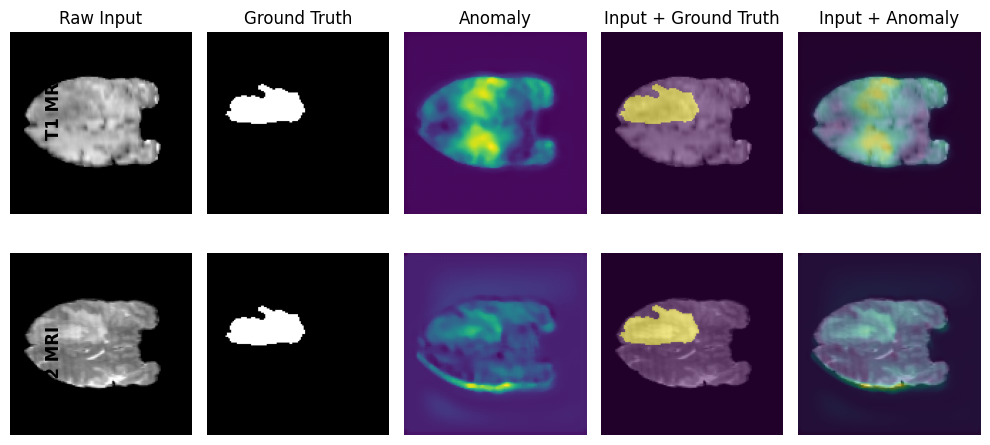

In [18]:
# Visualization of reconstructions 
brats_t1_raw = brats_t1_image.cpu().numpy()
brats_t1_anomaly = brats_t1_filtered_residual.numpy()
brats_t1_gt = brats_t1_ground_truth.numpy()

brats_t2_raw = brats_t2_image.cpu().numpy()
brats_t2_anomaly = brats_t2_filtered_residual.numpy()
brats_t2_gt = brats_t2_ground_truth.numpy()

# Create subplots 
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Extract middle slices along depth
brats_t1_raw_slice = brats_t1_raw[0, 0, :, 50, :]
brats_t1_anomaly_slice = brats_t1_anomaly[:, 50, :]  
brats_t1_gt_slice = brats_t1_gt[:, 50, :]

brats_t2_raw_slice = brats_t2_raw[0, 0, :, 50, :]
brats_t2_anomaly_slice = brats_t2_anomaly[:, 50, :]
brats_t2_gt_slice = brats_t2_gt[:, 50, :]

# Plot T1 slices (row 0)
axes[0,0].imshow(brats_t1_raw_slice, cmap="gray") 
axes[0,1].imshow(brats_t1_gt_slice, cmap="gray")
axes[0,2].imshow(brats_t1_anomaly_slice, cmap="viridis") 
axes[0,3].imshow(brats_t1_raw_slice, cmap="gray") 
axes[0,3].imshow(brats_t1_gt_slice, cmap="viridis", alpha=0.5) 
axes[0,4].imshow(brats_t1_raw_slice, cmap="gray") 
axes[0,4].imshow(brats_t1_anomaly_slice, cmap="viridis", alpha=0.5) 

# Plot T2 slices (row 1)
axes[1,0].imshow(brats_t2_raw_slice, cmap="gray") 
axes[1,1].imshow(brats_t2_gt_slice, cmap="gray")
axes[1,2].imshow(brats_t2_anomaly_slice, cmap="viridis") 
axes[1,3].imshow(brats_t2_raw_slice, cmap="gray") 
axes[1,3].imshow(brats_t2_gt_slice, cmap="viridis", alpha=0.5) 
axes[1,4].imshow(brats_t2_raw_slice, cmap="gray") 
axes[1,4].imshow(brats_t2_anomaly_slice, cmap="viridis", alpha=0.5)

# Remove axis labels
for row in range(2):
    for col in range(5):
        axes[row, col].axis("off")

# Set column titles
axes[0,0].set_title("Raw Input")
axes[0,1].set_title("Ground Truth")
axes[0,2].set_title("Anomaly")
axes[0,3].set_title("Input + Ground Truth")
axes[0,4].set_title("Input + Anomaly")

# Add row labels (T1 and T2) using fig.text()
fig.text(0.05, 0.75, "T1 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)
fig.text(0.05, 0.25, "T2 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)

plt.tight_layout()
plt.show()

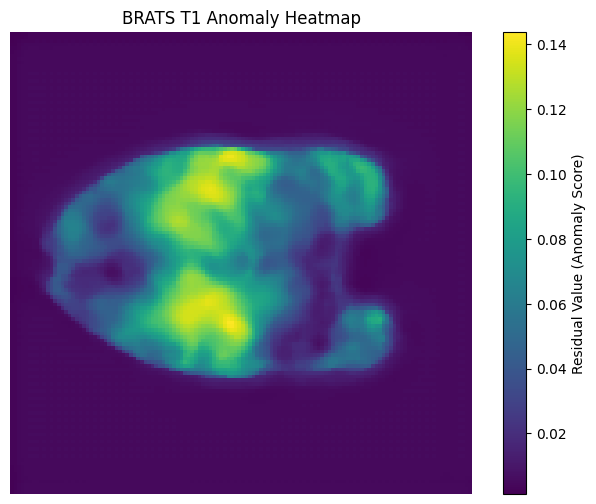

In [19]:
# Plot heatmap with colorbar
plt.figure(figsize=(8, 6))
brats_t1_heatmap = plt.imshow(brats_t1_anomaly_slice, cmap="viridis")   
plt.colorbar(brats_t1_heatmap, label="Residual Value (Anomaly Score)")  
plt.title("BRATS T1 Anomaly Heatmap")
plt.axis("off")
plt.show()

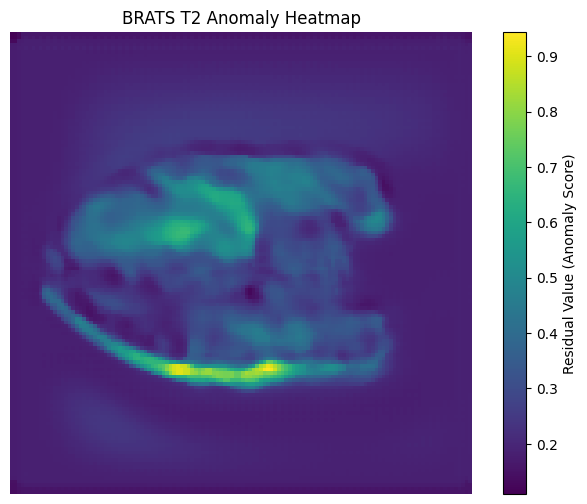

In [20]:
# Plot heatmap with colorbar
plt.figure(figsize=(8, 6))
brats_t2_heatmap = plt.imshow(brats_t2_anomaly_slice, cmap="viridis")   
plt.colorbar(brats_t2_heatmap, label="Residual Value (Anomaly Score)")  
plt.title("BRATS T2 Anomaly Heatmap")
plt.axis("off")
plt.show()
